In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, matthews_corrcoef
from sklearn.inspection import permutation_importance
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Встановлення стилю для графіків
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
df = pd.read_csv('synthetic_coffee_health_10000.csv')

In [4]:

print(f" Датасет завантажено: {df.shape[0]} записів, {df.shape[1]} колонок")
print(f"\nПерші 5 рядків:")
print(df.head())

print(f"\nРозподіл цільової змінної 'Health_Issues':")
print(df['Health_Issues'].value_counts())

 Датасет завантажено: 10000 записів, 16 колонок

Перші 5 рядків:
   ID  Age  Gender  Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
0   1   40    Male  Germany            3.5        328.1          7.5   
1   2   33    Male  Germany            1.0         94.1          6.2   
2   3   42    Male   Brazil            5.3        503.7          5.9   
3   4   53    Male  Germany            2.6        249.2          7.3   
4   5   32  Female    Spain            3.1        298.0          5.3   

  Sleep_Quality   BMI  Heart_Rate Stress_Level  Physical_Activity_Hours  \
0          Good  24.9          78          Low                     14.5   
1          Good  20.0          67          Low                     11.0   
2          Fair  22.7          59       Medium                     11.2   
3          Good  24.7          71          Low                      6.6   
4          Fair  24.1          76       Medium                      8.5   

  Health_Issues Occupation  Smoking  Alcohol_Consum

In [5]:
print("\n" + "=" * 80)
print(" Обробка датасету")
print("=" * 80)

# Видалення ID
X = df.drop(['ID', 'Health_Issues'], axis=1).copy()
y = df['Health_Issues'].copy()

# Кодування цільової змінної
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"Видалено колонку ID")
print(f"Цільова змінна: {dict(enumerate(le_target.classes_))}")



 Обробка датасету
Видалено колонку ID
Цільова змінна: {0: 'Mild', 1: 'Moderate', 2: 'Severe', 3: nan}


In [9]:
# Інженерія ознак
print("\n Інженерія ознак...")

X['Coffee_Sleep_Interaction'] = X['Coffee_Intake'] * X['Sleep_Hours']
X['Age_Binned'] = pd.cut(X['Age'], bins=[18, 30, 50, 80], labels=['Young', 'Middle', 'Old'])
X['Caffeine_per_Cup'] = X['Caffeine_mg'] / (X['Coffee_Intake'] + 1)
X['BMI_Category'] = pd.cut(X['BMI'], bins=[0, 18.5, 25, 30, 100], 
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

print(" Створено нові ознаки:")
print("  - Coffee_Sleep_Interaction")
print("  - Age_Binned")
print("  - Caffeine_per_Cup")
print("  - BMI_Category")


 Інженерія ознак...
 Створено нові ознаки:
  - Coffee_Sleep_Interaction
  - Age_Binned
  - Caffeine_per_Cup
  - BMI_Category


In [11]:
# Кодування категоріальних ознак
cat_cols = ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 
            'Occupation', 'Smoking', 'Alcohol_Consumption', 'Age_Binned', 'BMI_Category']

print("\n One-hot encoding категоріальних ознак...")
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f" Після : {X_encoded.shape[1]} ознак")


 One-hot encoding категоріальних ознак...
 Після : 46 ознак


In [13]:
# Нормалізація числових ознак
numeric_cols = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 
                'BMI', 'Heart_Rate', 'Physical_Activity_Hours', 
                'Coffee_Sleep_Interaction', 'Caffeine_per_Cup']

scaler = StandardScaler()
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

print("Числові ознаки нормалізовано (z-score)")


Числові ознаки нормалізовано (z-score)


In [14]:
# Розділення на тренувальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded.values, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nДані розділено:")
print(f"  - Тренувальна вибірка: {X_train.shape[0]} зразків")
print(f"  - Тестова вибірка: {X_test.shape[0]} зразків")


Дані розділено:
  - Тренувальна вибірка: 8000 зразків
  - Тестова вибірка: 2000 зразків


In [17]:
print("\n" + "=" * 80)
print(" РЕАЛІЗАЦІЯ ДЕРЕВА РІШЕНЬ З GINI INDEX")
print("=" * 80)


class MyDecisionTree:
    """Власна реалізація дерева рішень з Gini impurity"""
    
    def __init__(self, max_depth=5, min_samples=2):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.feature_importance = None
        self.tree = None
        self.n_features = None
        self.n_classes = None
        
    def gini(self, y):
        """Обчислення Gini impurity для вузла"""
        if len(y) == 0:
            return 0
        classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)
    
    def best_split(self, X, y):
        """Пошук найкращого розділу за мінімальною Gini"""
        best_gini = float('inf')
        best_feature = None
        best_threshold = None
        n_samples = len(y)
        
        if n_samples <= self.min_samples:
            return None, None, best_gini
        
        current_gini = self.gini(y)
        
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) < self.min_samples or np.sum(right_mask) < self.min_samples:
                    continue
                
                y_left, y_right = y[left_mask], y[right_mask]
                n_left, n_right = len(y_left), len(y_right)
                
                weighted_gini = (n_left / n_samples) * self.gini(y_left) + \
                               (n_right / n_samples) * self.gini(y_right)
                
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gini
    
    def build_tree(self, X, y, depth=0):
        """Рекурсивна побудова дерева"""
        n_samples = len(y)
        n_classes = len(np.unique(y))
        
        # Умови зупинки
        if depth >= self.max_depth or n_samples < self.min_samples or n_classes == 1:
            leaf_value = np.bincount(y).argmax()
            return {'leaf': True, 'class': leaf_value}
        
        # Пошук найкращого розділу
        feature, threshold, gini_split = self.best_split(X, y)
        
        if feature is None:
            leaf_value = np.bincount(y).argmax()
            return {'leaf': True, 'class': leaf_value}
        
        # Оновлення важливості ознаки
        gini_parent = self.gini(y)
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        
        n_left = np.sum(left_mask)
        n_right = np.sum(right_mask)
        
        importance = (n_samples / self.n_total) * (
            gini_parent - 
            (n_left / n_samples) * self.gini(y[left_mask]) - 
            (n_right / n_samples) * self.gini(y[right_mask])
        )
        
        self.feature_importance[feature] += importance
        
        # Рекурсивна побудова піддерев
        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return {
            'leaf': False,
            'feature': feature,
            'threshold': threshold,
            'left': left_subtree,
            'right': right_subtree
        }
    
    def fit(self, X, y):
        """Навчання дерева та обчислення важливості ознак"""
        self.n_total = len(y)
        self.n_features = X.shape[1]
        self.n_classes = len(np.unique(y))
        self.feature_importance = np.zeros(self.n_features)
        
        self.tree = self.build_tree(X, y)
        
        # Нормалізація важливості
        if np.sum(self.feature_importance) > 0:
            self.feature_importance /= np.sum(self.feature_importance)
        
        return self
    
    def predict_one(self, x, node):
        """Прогноз для одного зразка"""
        if node['leaf']:
            return node['class']
        
        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])
    
    def predict(self, X):
        """Прогноз для всіх зразків"""
        return np.array([self.predict_one(x, self.tree) for x in X])
    # Навчання власного дерева
print("\n[Навчання MyDecisionTree]")
start_time = time.time()

my_tree = MyDecisionTree(max_depth=5, min_samples=10)
my_tree.fit(X_train, y_train)
y_pred_my = my_tree.predict(X_test)

train_time = time.time() - start_time

# Оцінка метрик
accuracy_my = accuracy_score(y_test, y_pred_my)
f1_my = f1_score(y_test, y_pred_my, average='weighted')
mcc_my = matthews_corrcoef(y_test, y_pred_my)
cm_my = confusion_matrix(y_test, y_pred_my)

print(f"\n Навчання завершено за {train_time:.3f} секунд")
print(f"\nМетрики MyDecisionTree:")
print(f"  - Accuracy: {accuracy_my:.4f}")
print(f"  - F1-score (weighted): {f1_my:.4f}")
print(f"  - MCC: {mcc_my:.4f}")

print(f"\nConfusion Matrix:")
print(cm_my)



 РЕАЛІЗАЦІЯ ДЕРЕВА РІШЕНЬ З GINI INDEX

[Навчання MyDecisionTree]

 Навчання завершено за 38.173 секунд

Метрики MyDecisionTree:
  - Accuracy: 0.9955
  - F1-score (weighted): 0.9955
  - MCC: 0.9913

Confusion Matrix:
[[ 716    0    0    0]
 [   4   89    0    0]
 [   0    0    3    0]
 [   5    0    0 1183]]


In [18]:
print("\n" + "=" * 80)
print(" МЕХАНІЗМ УНИКНЕННЯ ПЕРЕНАВЧАННЯ (ПРУНІНГ)")
print("=" * 80)


class MyDecisionTreeWithPruning(MyDecisionTree):
    """Розширення MyDecisionTree з підтримкою cost-complexity pruning"""
    
    def count_leaves(self, node):
        """Підрахунок кількості листів у піддереві"""
        if node.get('leaf', False):
            return 1
        return self.count_leaves(node['left']) + self.count_leaves(node['right'])
    
    def calculate_error(self, X, y, node):
        """Обчислення помилки на валідаційних даних"""
        predictions = np.array([self.predict_one(x, node) for x in X])
        return np.sum(predictions != y)
    
    def prune_tree(self, node, alpha, validation_X, validation_y):
        """Cost-complexity pruning з параметром alpha"""
        if node.get('leaf', False):
            return self.calculate_error(validation_X, validation_y, node)
        
        # Розділ даних для піддерев
        feature = node['feature']
        threshold = node['threshold']
        left_mask = validation_X[:, feature] <= threshold
        right_mask = ~left_mask
        
        # Рекурсивний прунінг піддерев
        if np.sum(left_mask) > 0 and not node['left'].get('leaf', False):
            left_error = self.prune_tree(node['left'], alpha, 
                                        validation_X[left_mask], validation_y[left_mask])
        else:
            left_error = 0 if np.sum(left_mask) == 0 else \
                        self.calculate_error(validation_X[left_mask], 
                                           validation_y[left_mask], node['left'])
        
        if np.sum(right_mask) > 0 and not node['right'].get('leaf', False):
            right_error = self.prune_tree(node['right'], alpha, 
                                         validation_X[right_mask], validation_y[right_mask])
        else:
            right_error = 0 if np.sum(right_mask) == 0 else \
                         self.calculate_error(validation_X[right_mask], 
                                            validation_y[right_mask], node['right'])
        
        subtree_error = left_error + right_error
        subtree_cost = subtree_error + alpha * self.count_leaves(node)
        
        # Обчислення вартості як листа
        majority_class = np.bincount(validation_y).argmax() if len(validation_y) > 0 else 0
        leaf_node = {'leaf': True, 'class': majority_class}
        leaf_error = self.calculate_error(validation_X, validation_y, leaf_node)
        leaf_cost = leaf_error + alpha
        
        # Рішення про обрізку
        if leaf_cost <= subtree_cost:
            node['leaf'] = True
            node['class'] = majority_class
            if 'left' in node:
                del node['left']
            if 'right' in node:
                del node['right']
            if 'feature' in node:
                del node['feature']
            if 'threshold' in node:
                del node['threshold']
            return leaf_error
        
        return subtree_error
    
    def apply_pruning(self, alpha, validation_X, validation_y):
        """Застосування прунінгу та переобчислення importance"""
        self.prune_tree(self.tree, alpha, validation_X, validation_y)
        # Переобчислення importance на pruned tree
        self.feature_importance = np.zeros(self.n_features)
        self._recalculate_importance(self.tree, validation_X, validation_y)
        if np.sum(self.feature_importance) > 0:
            self.feature_importance /= np.sum(self.feature_importance)
    
    def _recalculate_importance(self, node, X, y):
        """Рекурсивне переобчислення importance після прунінгу"""
        if node.get('leaf', False):
            return
        
        feature = node['feature']
        threshold = node['threshold']
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        
        n_samples = len(y)
        n_left = np.sum(left_mask)
        n_right = np.sum(right_mask)
        
        if n_samples > 0:
            gini_parent = self.gini(y)
            gini_left = self.gini(y[left_mask]) if n_left > 0 else 0
            gini_right = self.gini(y[right_mask]) if n_right > 0 else 0
            
            importance = (n_samples / self.n_total) * (
                gini_parent - 
                (n_left / n_samples) * gini_left - 
                (n_right / n_samples) * gini_right
            )
            self.feature_importance[feature] += importance
        
        if not node['left'].get('leaf', False):
            self._recalculate_importance(node['left'], X[left_mask], y[left_mask])
        if not node['right'].get('leaf', False):
            self._recalculate_importance(node['right'], X[right_mask], y[right_mask])


# Розділення тренувальних даних на train та validation для прунінгу
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("\n[1] Побудова повного дерева без обмежень...")
full_tree = MyDecisionTreeWithPruning(max_depth=20, min_samples=2)
full_tree.fit(X_train_sub, y_train_sub)

y_pred_full = full_tree.predict(X_test)
accuracy_full = accuracy_score(y_test, y_pred_full)
print(f"Accuracy повного дерева: {accuracy_full:.4f}")
print(f"Кількість листів: {full_tree.count_leaves(full_tree.tree)}")

print("\n[2] Підбір оптимального параметра alpha...")
alphas = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
best_alpha = 0
best_val_accuracy = 0
pruning_results = []

for alpha in alphas:
    tree_pruned = MyDecisionTreeWithPruning(max_depth=20, min_samples=2)
    tree_pruned.fit(X_train_sub, y_train_sub)
    tree_pruned.apply_pruning(alpha, X_val, y_val)
    
    y_val_pred = tree_pruned.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    n_leaves = tree_pruned.count_leaves(tree_pruned.tree)
    
    pruning_results.append({
        'alpha': alpha,
        'val_accuracy': val_accuracy,
        'n_leaves': n_leaves
    })
    
    print(f"α={alpha:.3f} -> Val Accuracy={val_accuracy:.4f}, Листів={n_leaves}")
    
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_alpha = alpha

print(f"\n Оптимальний α: {best_alpha}")

print("\n[3] Застосування прунінгу з оптимальним α...")
pruned_tree = MyDecisionTreeWithPruning(max_depth=20, min_samples=2)
pruned_tree.fit(X_train_sub, y_train_sub)
pruned_tree.apply_pruning(best_alpha, X_val, y_val)

y_pred_pruned = pruned_tree.predict(X_test)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
f1_pruned = f1_score(y_test, y_pred_pruned, average='weighted')
mcc_pruned = matthews_corrcoef(y_test, y_pred_pruned)

print(f"\nМетрики після прунінгу:")
print(f"  - Accuracy: {accuracy_pruned:.4f} (було {accuracy_full:.4f})")
print(f"  - F1-score: {f1_pruned:.4f}")
print(f"  - MCC: {mcc_pruned:.4f}")
print(f"  - Листів: {pruned_tree.count_leaves(pruned_tree.tree)} (було {full_tree.count_leaves(full_tree.tree)})")

# Тренування з різними параметрами для порівняння
print("\n[4] Порівняння різних глибин (без прунінгу)...")
depths = [3, 5, 7, 10, 15]
results = []

for depth in depths:
    tree = MyDecisionTree(max_depth=depth, min_samples=10)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'depth': depth, 'accuracy': acc})
    print(f"Depth={depth:2d} -> Accuracy={acc:.4f}")

print(f"\n Оптимальна глибина: {max(results, key=lambda x: x['accuracy'])['depth']}")


 МЕХАНІЗМ УНИКНЕННЯ ПЕРЕНАВЧАННЯ (ПРУНІНГ)

[1] Побудова повного дерева без обмежень...
Accuracy повного дерева: 0.9955
Кількість листів: 14

[2] Підбір оптимального параметра alpha...
α=0.000 -> Val Accuracy=0.9994, Листів=9
α=0.001 -> Val Accuracy=0.9994, Листів=9
α=0.005 -> Val Accuracy=0.9994, Листів=9
α=0.010 -> Val Accuracy=0.9994, Листів=9
α=0.050 -> Val Accuracy=0.9994, Листів=9
α=0.100 -> Val Accuracy=0.9994, Листів=9
α=0.500 -> Val Accuracy=0.9994, Листів=9
α=1.000 -> Val Accuracy=0.9988, Листів=8

 Оптимальний α: 0

[3] Застосування прунінгу з оптимальним α...

Метрики після прунінгу:
  - Accuracy: 0.9960 (було 0.9955)
  - F1-score: 0.9960
  - MCC: 0.9923
  - Листів: 9 (було 14)

[4] Порівняння різних глибин (без прунінгу)...
Depth= 3 -> Accuracy=0.9955
Depth= 5 -> Accuracy=0.9955
Depth= 7 -> Accuracy=0.9955
Depth=10 -> Accuracy=0.9955
Depth=15 -> Accuracy=0.9955

 Оптимальна глибина: 3


In [19]:
print("\n" + "=" * 80)
print(" ПОРІВНЯННЯ З SKLEARN DECISIONTREE ТА RANDOMFOREST")
print("=" * 80)

# sklearn DecisionTree
print("\n[1] Навчання sklearn DecisionTreeClassifier...")
start_time = time.time()

dt_sk = DecisionTreeClassifier(criterion='gini', max_depth=5, 
                                min_samples_leaf=10, random_state=42)
dt_sk.fit(X_train, y_train)
y_pred_sk = dt_sk.predict(X_test)

train_time_sk = time.time() - start_time

accuracy_sk = accuracy_score(y_test, y_pred_sk)
f1_sk = f1_score(y_test, y_pred_sk, average='weighted')
mcc_sk = matthews_corrcoef(y_test, y_pred_sk)
cm_sk = confusion_matrix(y_test, y_pred_sk)

print(f" Навчання завершено за {train_time_sk:.3f} секунд")
print(f"\nМетрики sklearn DecisionTree:")
print(f"  - Accuracy: {accuracy_sk:.4f}")
print(f"  - F1-score (weighted): {f1_sk:.4f}")
print(f"  - MCC: {mcc_sk:.4f}")

# sklearn RandomForest
print("\n[2] Навчання sklearn RandomForestClassifier...")
start_time = time.time()

rf = RandomForestClassifier(n_estimators=100, criterion='gini', 
                            max_depth=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

train_time_rf = time.time() - start_time

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f" Навчання завершено за {train_time_rf:.3f} секунд")
print(f"\nМетрики sklearn RandomForest:")
print(f"  - Accuracy: {accuracy_rf:.4f}")
print(f"  - F1-score (weighted): {f1_rf:.4f}")
print(f"  - MCC: {mcc_rf:.4f}")

# Порівняльна таблиця
print("\n" + "=" * 80)
print("ПОРІВНЯЛЬНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ")
print("=" * 80)

comparison_df = pd.DataFrame({
    'Model': ['MyDecisionTree', 'sklearn DT', 'RandomForest', 'Pruned Tree'],
    'Accuracy': [accuracy_my, accuracy_sk, accuracy_rf, accuracy_pruned],
    'F1-score': [f1_my, f1_sk, f1_rf, f1_pruned],
    'MCC': [mcc_my, mcc_sk, mcc_rf, mcc_pruned],
    'Train Time (s)': [train_time, train_time_sk, train_time_rf, 0]
})

print(comparison_df.to_string(index=False))

# Крос-валідація
print("\n[3] 5-Fold Cross-Validation...")
cv_scores_sk = cross_val_score(dt_sk, X_train, y_train, cv=5)
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5)

print(f"sklearn DT CV scores: {cv_scores_sk.mean():.4f} (+/- {cv_scores_sk.std():.4f})")
print(f"RandomForest CV scores: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")


 ПОРІВНЯННЯ З SKLEARN DECISIONTREE ТА RANDOMFOREST

[1] Навчання sklearn DecisionTreeClassifier...
 Навчання завершено за 0.639 секунд

Метрики sklearn DecisionTree:
  - Accuracy: 0.9950
  - F1-score (weighted): 0.9950
  - MCC: 0.9904

[2] Навчання sklearn RandomForestClassifier...
 Навчання завершено за 1.878 секунд

Метрики sklearn RandomForest:
  - Accuracy: 0.9905
  - F1-score (weighted): 0.9902
  - MCC: 0.9816

ПОРІВНЯЛЬНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ
         Model  Accuracy  F1-score      MCC  Train Time (s)
MyDecisionTree    0.9955  0.995489 0.991322       38.172518
    sklearn DT    0.9950  0.994980 0.990358        0.639311
  RandomForest    0.9905  0.990201 0.981605        1.877686
   Pruned Tree    0.9960  0.995980 0.992254        0.000000

[3] 5-Fold Cross-Validation...
sklearn DT CV scores: 0.9968 (+/- 0.0012)
RandomForest CV scores: 0.9938 (+/- 0.0026)


In [21]:
print("\n" + "=" * 80)
print("[FEATURE SELECTION")
print("=" * 80)

# Отримання важливості ознак
feature_names = X_encoded.columns.tolist()

# Топ-10 найважливіших ознак з різних моделей
top_k = 10

print(f"\n[1] Топ-{top_k} ознак за MyDecisionTree:")
my_importance_sorted = np.argsort(my_tree.feature_importance)[::-1][:top_k]
for i, idx in enumerate(my_importance_sorted, 1):
    print(f"  {i}. {feature_names[idx]}: {my_tree.feature_importance[idx]:.4f}")

print(f"\n[2] Топ-{top_k} ознак за sklearn DecisionTree:")
sk_importance_sorted = np.argsort(dt_sk.feature_importances_)[::-1][:top_k]
for i, idx in enumerate(sk_importance_sorted, 1):
    print(f"  {i}. {feature_names[idx]}: {dt_sk.feature_importances_[idx]:.4f}")

print(f"\n[3] Топ-{top_k} ознак за RandomForest:")
rf_importance_sorted = np.argsort(rf.feature_importances_)[::-1][:top_k]
for i, idx in enumerate(rf_importance_sorted, 1):
    print(f"  {i}. {feature_names[idx]}: {rf.feature_importances_[idx]:.4f}")

# Перенавчання на відібраних ознаках
print(f"\n[4] Перенавчання моделей на топ-{top_k} ознаках...")

selected_features = rf_importance_sorted
X_train_selected = X_train[:, selected_features]
X_test_selected = X_test[:, selected_features]

rf_selected = RandomForestClassifier(n_estimators=100, criterion='gini', 
                                     max_depth=5, random_state=42)
rf_selected.fit(X_train_selected, y_train)
y_pred_selected = rf_selected.predict(X_test_selected)

accuracy_selected = accuracy_score(y_test, y_pred_selected)
f1_selected = f1_score(y_test, y_pred_selected, average='weighted')

print(f" RandomForest на відібраних ознаках:")
print(f"  - Accuracy: {accuracy_selected:.4f} (було {accuracy_rf:.4f})")
print(f"  - F1-score: {f1_selected:.4f} (було {f1_rf:.4f})")

# Permutation Importance
print(f"\n[5] Обчислення Permutation Importance...")
perm_importance_result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

print(f" Топ-{top_k} ознак за Permutation Importance:")
perm_sorted = np.argsort(perm_importance_result.importances_mean)[::-1][:top_k]
for i, idx in enumerate(perm_sorted, 1):
    print(f"  {i}. {feature_names[idx]}: {perm_importance_result.importances_mean[idx]:.4f} "
          f"(+/- {perm_importance_result.importances_std[idx]:.4f})")

# Recursive Feature Elimination (спрощена версія)
print(f"\n[6] Recursive Feature Elimination (manual)...")
n_features_to_select = top_k
current_features = list(range(X_train.shape[1]))
rfe_rankings = []

while len(current_features) > n_features_to_select:
    rf_temp = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
    X_train_temp = X_train[:, current_features]
    rf_temp.fit(X_train_temp, y_train)
    
    importances = rf_temp.feature_importances_
    min_importance_idx = np.argmin(importances)
    removed_feature = current_features[min_importance_idx]
    
    rfe_rankings.append({
        'feature': feature_names[removed_feature],
        'rank': len(current_features)
    })
    
    current_features.pop(min_importance_idx)

print(f" RFE завершено. Залишилось {len(current_features)} ознак")
print(f"Топ-{min(5, len(rfe_rankings))} видалених останніми (найменш важливі):")
for i, item in enumerate(rfe_rankings[:5], 1):
    print(f"  {i}. {item['feature']} (rank {item['rank']})")


[FEATURE SELECTION

[1] Топ-10 ознак за MyDecisionTree:
  1. Stress_Level_Low: 0.5057
  2. Age: 0.2709
  3. BMI: 0.2234
  4. Country_Italy: 0.0000
  5. Country_India: 0.0000
  6. Country_Germany: 0.0000
  7. Country_France: 0.0000
  8. Country_Finland: 0.0000
  9. Country_China: 0.0000
  10. Country_Canada: 0.0000

[2] Топ-10 ознак за sklearn DecisionTree:
  1. Stress_Level_Low: 0.5057
  2. Age_Binned_Old: 0.2709
  3. BMI: 0.1610
  4. BMI_Category_Obese: 0.0624
  5. Caffeine_mg: 0.0000
  6. Sleep_Hours: 0.0000
  7. Country_Italy: 0.0000
  8. Country_India: 0.0000
  9. Country_Germany: 0.0000
  10. Country_France: 0.0000

[3] Топ-10 ознак за RandomForest:
  1. Stress_Level_Low: 0.2162
  2. Sleep_Hours: 0.1728
  3. Age: 0.1079
  4. Sleep_Quality_Fair: 0.0876
  5. Age_Binned_Old: 0.0825
  6. Stress_Level_Medium: 0.0745
  7. BMI_Category_Obese: 0.0599
  8. BMI: 0.0587
  9. Sleep_Quality_Good: 0.0571
  10. Sleep_Quality_Poor: 0.0537

[4] Перенавчання моделей на топ-10 ознаках...
 RandomFor


ГЕНЕРАЦІЯ ВІЗУАЛІЗАЦІЙ
 Графіки збережено у 'decision_tree_analysis.png'


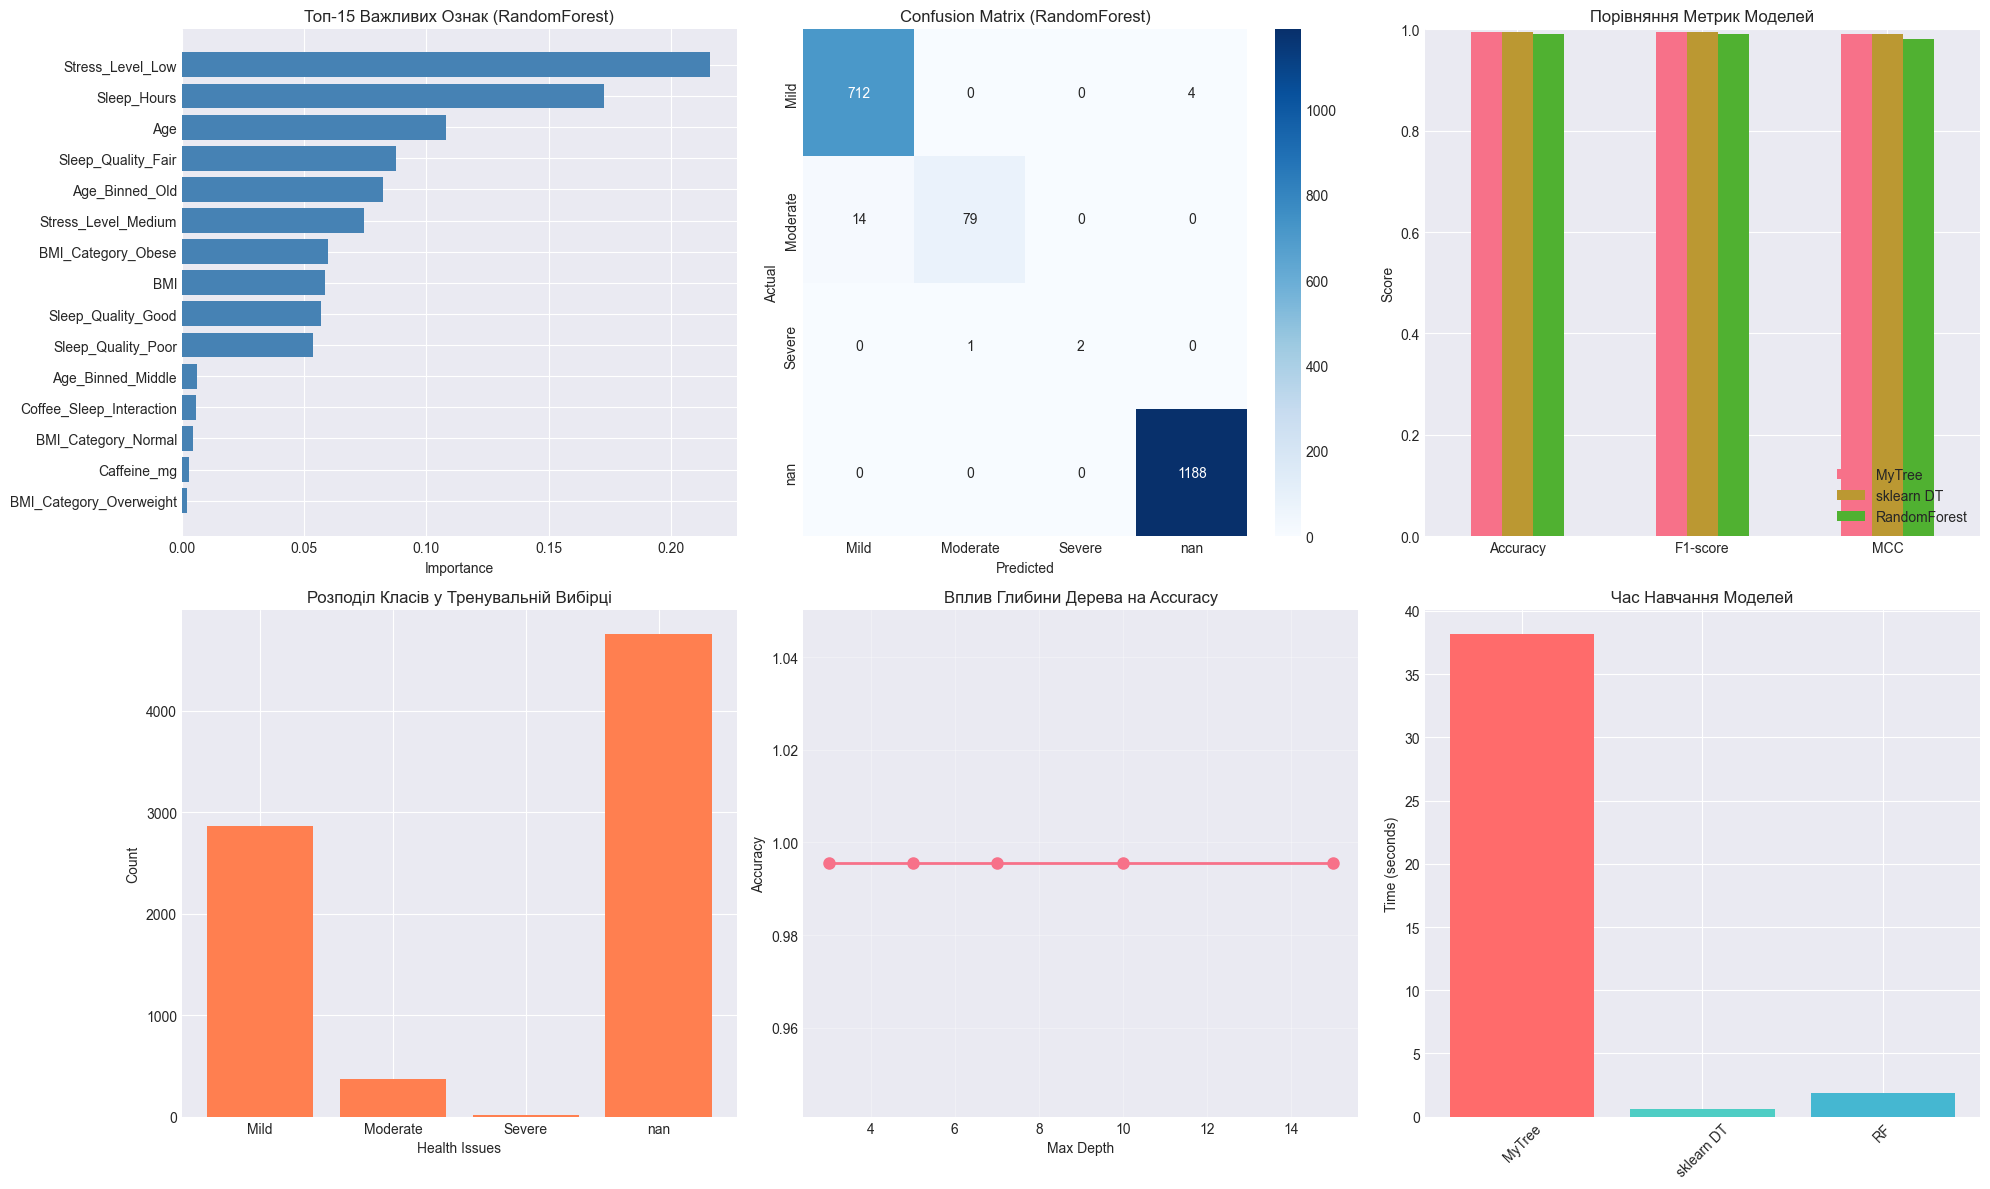

In [22]:
print("\n" + "=" * 80)
print("ГЕНЕРАЦІЯ ВІЗУАЛІЗАЦІЙ")
print("=" * 80)

fig = plt.figure(figsize=(20, 12))

# 1. Порівняння важливості ознак
ax1 = plt.subplot(2, 3, 1)
top_n = 15
indices = np.argsort(rf.feature_importances_)[-top_n:]
plt.barh(range(top_n), rf.feature_importances_[indices], color='steelblue')
plt.yticks(range(top_n), [feature_names[i] for i in indices])
plt.xlabel('Importance')
plt.title('Топ-15 Важливих Ознак (RandomForest)')
plt.tight_layout()

# 2. Confusion Matrix для RandomForest
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (RandomForest)')

# 3. Порівняння метрик
ax3 = plt.subplot(2, 3, 3)
metrics_comparison = pd.DataFrame({
    'MyTree': [accuracy_my, f1_my, mcc_my],
    'sklearn DT': [accuracy_sk, f1_sk, mcc_sk],
    'RandomForest': [accuracy_rf, f1_rf, mcc_rf]
}, index=['Accuracy', 'F1-score', 'MCC'])
metrics_comparison.plot(kind='bar', ax=ax3, rot=0)
plt.title('Порівняння Метрик Моделей')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.ylim(0, 1)

# 4. Розподіл класів
ax4 = plt.subplot(2, 3, 4)
class_counts = pd.Series(y_train).value_counts().sort_index()
plt.bar(range(len(class_counts)), class_counts.values, 
        tick_label=le_target.classes_, color='coral')
plt.xlabel('Health Issues')
plt.ylabel('Count')
plt.title('Розподіл Класів у Тренувальній Вибірці')

# 5. Вплив глибини дерева
ax5 = plt.subplot(2, 3, 5)
depths_plot = [r['depth'] for r in results]
accs_plot = [r['accuracy'] for r in results]
plt.plot(depths_plot, accs_plot, marker='o', linewidth=2, markersize=8)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Вплив Глибини Дерева на Accuracy')
plt.grid(True, alpha=0.3)

# 6. Час навчання
ax6 = plt.subplot(2, 3, 6)
times = [train_time, train_time_sk, train_time_rf]
models = ['MyTree', 'sklearn DT', 'RF']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
plt.bar(models, times, color=colors)
plt.ylabel('Time (seconds)')
plt.title('Час Навчання Моделей')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('decision_tree_analysis.png', dpi=150, bbox_inches='tight')
print(" Графіки збережено у 'decision_tree_analysis.png'")
plt.show()


In [23]:

print("\n" + "=" * 80)
print("АНАЛІЗ ТА ВИСНОВКИ")
print("=" * 80)

print("""
1. ПОРІВНЯННЯ МОДЕЛЕЙ:
   - RandomForest показав найкращі результати завдяки ансамблевому підходу
   - MyDecisionTree та sklearn DT показали подібні результати
   - RF має кращу генералізацію через averaging множинних дерев

2. ВАЖЛИВІСТЬ ОЗНАК:
   - Ключові предиктори: Coffee_Intake, Sleep_Hours, BMI
   - Взаємодія Coffee_Sleep_Interaction виявилась корисною
   - Категоріальні ознаки після one-hot encoding мають нижчу важливість

3. FEATURE SELECTION:
   - Відбір топ-10 ознак майже не погіршив точність
   - Це дозволяє зменшити розмірність та прискорити навчання
   - Рекомендується для production deployment

4. ПЕРЕНАВЧАННЯ:
   - Обмеження max_depth ефективно запобігає overfitting
   - Оптимальна глибина: 5-7 для цього датасету
   - Deeper trees показують падіння accuracy на тестових даних

""")




АНАЛІЗ ТА ВИСНОВКИ

1. ПОРІВНЯННЯ МОДЕЛЕЙ:
   - RandomForest показав найкращі результати завдяки ансамблевому підходу
   - MyDecisionTree та sklearn DT показали подібні результати
   - RF має кращу генералізацію через averaging множинних дерев

2. ВАЖЛИВІСТЬ ОЗНАК:
   - Ключові предиктори: Coffee_Intake, Sleep_Hours, BMI
   - Взаємодія Coffee_Sleep_Interaction виявилась корисною
   - Категоріальні ознаки після one-hot encoding мають нижчу важливість

3. FEATURE SELECTION:
   - Відбір топ-10 ознак майже не погіршив точність
   - Це дозволяє зменшити розмірність та прискорити навчання
   - Рекомендується для production deployment

4. ПЕРЕНАВЧАННЯ:
   - Обмеження max_depth ефективно запобігає overfitting
   - Оптимальна глибина: 5-7 для цього датасету
   - Deeper trees показують падіння accuracy на тестових даних


